In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# loading utility files

from utility.sv_fig import savefig


In [3]:
# updated savefig due to bounding box issues
def savefig(filename, crop=False):
    fig = plt.gcf()

    import matplotlib as mpl
    mpl.rcParams['savefig.bbox'] = None

    fig.savefig(
        f"{filename}.pdf",
        bbox_inches=None,
        pad_inches=0,
        dpi=300
    )

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
data = pd.read_csv('data/Xy_Yes_No_md.csv')

print(data.shape)

(74, 16)


In [5]:

data = data.rename(columns={'Age_at_Surgery': 'Age at Surgery'})
data = data.rename(columns={'cT_or_pT': 'cT or pT'})
data = data.rename(columns={'Bx_Histology': 'Bx Histology'})
data = data.rename(columns={'Sample_weight': 'Sample weight'})
data = data.rename(columns={'Tumor_digest_count': 'Tumor digest count'})
data = data.rename(columns={'Fragments_plated': 'Fragments plated'})

In [6]:
all_col_names = data.columns.tolist()

print(all_col_names)

['Age at Surgery', 'Race', 'Surgery', 'Smoker', 'BMI', 'NAC', 'cT', 'pT', 'cT or pT', 'pN', 'Bx Histology', 'Histology', 'Sample weight', 'Tumor digest count', 'Fragments plated', 'OverallTILGrowth']


In [7]:
col_names = all_col_names[:-1]

print(col_names)

['Age at Surgery', 'Race', 'Surgery', 'Smoker', 'BMI', 'NAC', 'cT', 'pT', 'cT or pT', 'pN', 'Bx Histology', 'Histology', 'Sample weight', 'Tumor digest count', 'Fragments plated']


In [8]:
# corelation feature and target

ndata_nwy = data

print(ndata_nwy.shape)

X_cor = ndata_nwy.drop('OverallTILGrowth', axis=1)

# convert column "OverallTILGrowth" of Ndata to numerics
ndata_nwy['OverallTILGrowth'] = pd.to_numeric(ndata_nwy['OverallTILGrowth'])
y_cor = ndata_nwy['OverallTILGrowth']


# print(y_cor)
# print(X_cor)

feat_cols = list(X_cor.columns)

feat_cor_targ = r_regression(X_cor, y_cor, center=True, force_finite=True)
feat_cor_targ = list(feat_cor_targ)

# print(feat_cols)
# print(feat_cor_targ)

print("Corelation with OverallTILGrowth")
for feature in zip(feat_cols, feat_cor_targ):
    print(feature)



(74, 16)
Corelation with OverallTILGrowth
('Age at Surgery', -0.0892040899258394)
('Race', -0.16219222183503318)
('Surgery', -0.21884238755804317)
('Smoker', 0.06419727740004512)
('BMI', 0.04329824343984757)
('NAC', -0.018377261547332296)
('cT', 0.22677980365766873)
('pT', 0.05411552433036292)
('cT or pT', 0.21908072935486692)
('pN', -0.023836393366219028)
('Bx Histology', 0.21949168078954456)
('Histology', 0.11429218135123825)
('Sample weight', 0.09418244178887078)
('Tumor digest count', 0.13855431863926465)
('Fragments plated', 0.30320242877943865)


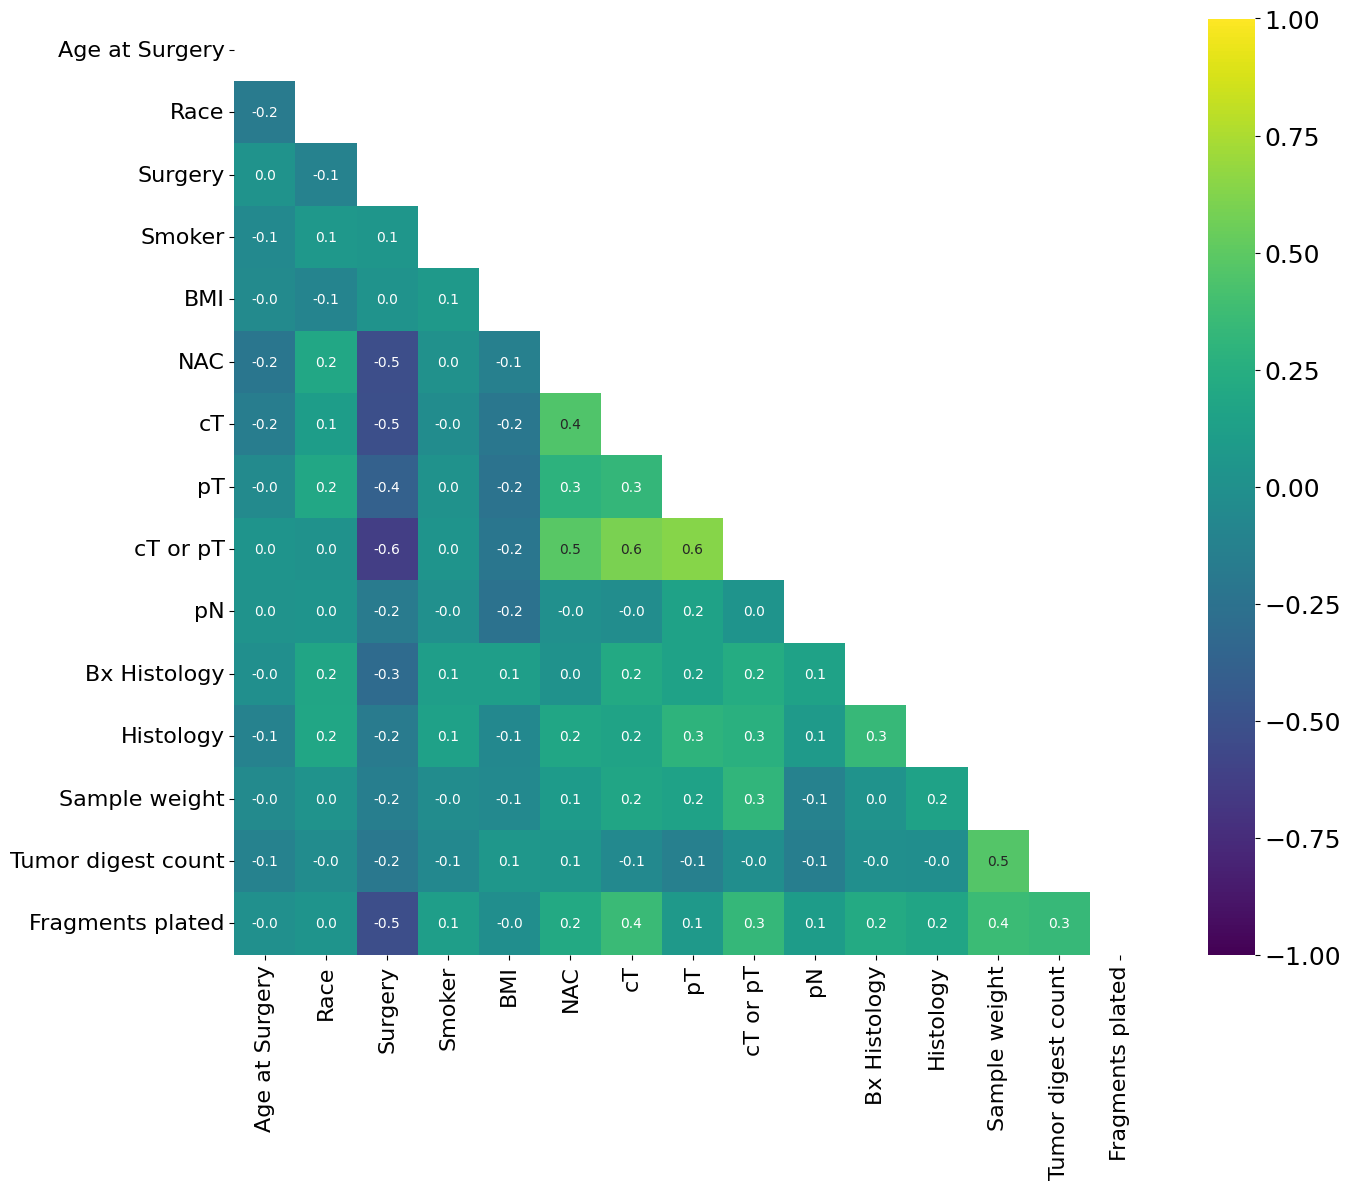

In [9]:

# Convert to pandas dataframe 
df_data = pd.DataFrame(data=data, 
                    columns=col_names)

plt.figure(figsize=(14, 12))
corr = df_data.corr() 
mask = np.tri(*corr.shape).T 

ax = sns.heatmap(corr, vmax=1, vmin=-1, mask=mask, annot=True, cmap='viridis', fmt=".1f", annot_kws={"size": 10})

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)

# Adjust the font size of the x and y tick labels
ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)

plt.tight_layout()

savefig('./figs/Yes_No_p_corr')
